# 04 — Gain-stage coloration: what does the model produce beyond the multiply?

**No training.** `MODEL_GAIN_PRIOR.md` §5.2 leaves one question open: the trained
model's waveform metrics parked at the amplitude-match level, i.e. the coloration
residual (≈ 8 % RMS: harmonics, transient micro-shaping) is apparently *not* being
modelled. This notebook measures that directly on the deployed **`GainPriorWSE2ELSTM`**
(09_end2end stage 2, the waveshaper cascade model). To isolate the coloration
*mechanism* it feeds the stage the **oracle** GR (the true wet/dry gain), so the
target residual is the pure coloration the multiply cannot explain — not conflated
with stage-1 prediction error (which is what notebooks 05–07 characterise for the
full cascade). The bench tests feed a synthetic constant GR, so they are
GR-source-independent by construction.

1. **Residual accounting on real data** — split the target residual
   `r_t = wet − amp_match` against the model residual `r_m = pred − amp_match`,
   and decompose `r_m` into its *gain* part (`x·10^((gr+Δg)/20) − amp`) and its
   *coloration* part (`(W(s)−s)+c`). Explained-fraction and spectral comparison →
   is the color path doing anything at all?
2. **Harmonic bench test** — steady sines at swept levels under constant GR →
   THD and harmonic series of the *learned device*. The amplitude match is
   harmonic-free by construction, so anything above the numerical floor is
   generated by the network.
3. **Waveshaper curve analysis** — exact harmonic series of the learned
   transfer curve via Fourier analysis of `W(A·cosθ)`, per drive level; even/odd
   split (curve asymmetry ↔ even harmonics).
4. **Δg behaviour** — where does the model override the prior? Joint statistics of
   Δg vs compression depth and vs signal level.

> Runs on the e2e waveshaper run by default; point `SELECTED_GAIN_PRIOR_RUN` at any
> other `GainPriorWSE2ELSTM` run to compare. ~5 min on CPU.

In [1]:
# -- 0. Setup --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.signal import welch

from exp_common import (
    SR, amp_to_db, amplitude_match, ensure_eval_out, harmonic_levels, knobs,
    load_gain_prior_e2e, load_pair, load_split, on_bin_freq, pairs_from_keys,
    params_for, sine, stream_gain_prior_parts, waveshaper_harmonics,
)

# Deployed e2e gain-prior waveshaper stage (09_end2end). Fed ORACLE GR here so the
# coloration residual is measured against the true gain (isolation); the full
# predicted-GR cascade is characterised in notebooks 05-07.
SELECTED_GAIN_PRIOR_RUN = "e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr"

MODEL, HP, RUN_DIR = load_gain_prior_e2e(SELECTED_GAIN_PRIOR_RUN)
SPLIT = load_split(RUN_DIR)
VAL_PAIRS = pairs_from_keys(SPLIT.val_pair_keys)
OUT = ensure_eval_out()
TAG = "ws" if hasattr(MODEL, "waveshaper") else "additive"
print(f"variant: {TAG} | matched_input={HP['model'].get('use_matched_input')}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 8,418-param GainPriorWSE2ELSTM  (e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr / best-086-1305000.ckpt)  matched_input=True
variant: ws | matched_input=True


AncoraQui / threshold_0_attack_3_release_0.8_ratio_4  (ws run)
  target residual      rms(r_t)/rms(wet) = 19.25%
  model residual       rms(r_m)/rms(wet) =  7.69%
    gain (delta-g) share   rms =  5.65%
    coloration share       rms =  5.09%
  explained fraction of residual energy: 13.72%
  corr(r_m, r_t) = 0.371


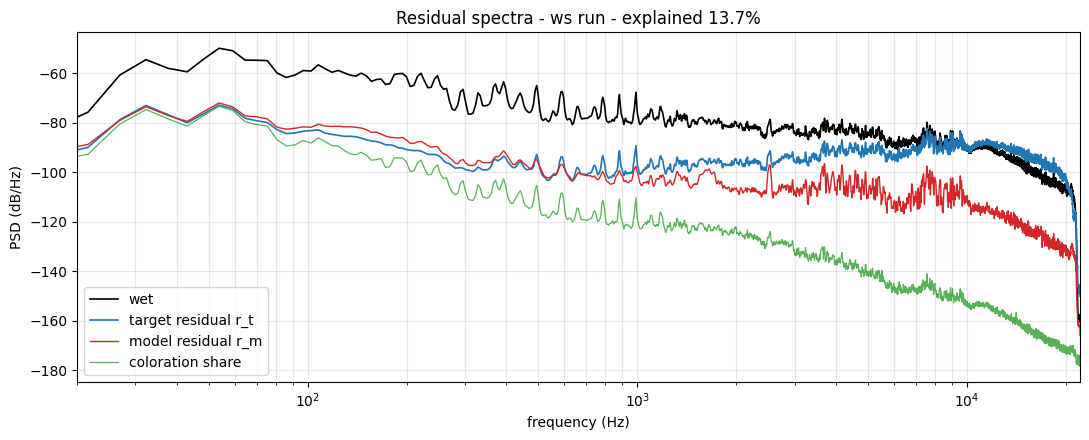

In [2]:
# -- 1. Residual accounting on real data -----------------------------------
# 60 s of a validation pair. All residuals are measured against the amplitude
# match (the model's own zero-init starting point).

song, setting = VAL_PAIRS[len(VAL_PAIRS) // 2]
dry, wet, gr = load_pair(setting, song, start_sec=30.0, duration_sec=60.0)
p = params_for(setting)

pred, delta_db, res_color = stream_gain_prior_parts(MODEL, dry, gr, p)
amp = amplitude_match(dry, gr)
r_t = (wet - amp)[0].numpy()            # target residual (what coloration must explain)
r_m = (pred - amp)[0].numpy()           # model residual (what the network added)
r_color = res_color[0].numpy()          # non-gain share (c, or (W-id)+c)
r_gain = r_m - r_color                  # gain share (from delta_g)

rms = lambda x: float(np.sqrt(np.mean(x ** 2)))
explained = 1 - rms(r_t - r_m) ** 2 / rms(r_t) ** 2
corr = float(np.corrcoef(r_t, r_m)[0, 1])
print(f"{song} / {setting}  ({TAG} run)")
print(f"  target residual      rms(r_t)/rms(wet) = {rms(r_t)/rms(wet[0].numpy()):6.2%}")
print(f"  model residual       rms(r_m)/rms(wet) = {rms(r_m)/rms(wet[0].numpy()):6.2%}")
print(f"    gain (delta-g) share   rms = {rms(r_gain)/rms(wet[0].numpy()):6.2%}")
print(f"    coloration share       rms = {rms(r_color)/rms(wet[0].numpy()):6.2%}")
print(f"  explained fraction of residual energy: {explained:6.2%}")
print(f"  corr(r_m, r_t) = {corr:.3f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
for sig, name, style in ((wet[0].numpy(), "wet", dict(color="k", lw=1.2)),
                         (r_t, "target residual r_t", dict(color="#1f77b4", lw=1.2)),
                         (r_m, "model residual r_m", dict(color="#d62728", lw=1.0)),
                         (r_color, "coloration share", dict(color="#2ca02c", lw=0.9, alpha=0.8))):
    f, Pxx = welch(sig, fs=SR, nperseg=8192)
    ax.semilogx(f, 10 * np.log10(Pxx + 1e-18), label=name, **style)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("PSD (dB/Hz)")
ax.set_title(f"Residual spectra - {TAG} run - explained {explained:.1%}")
ax.grid(alpha=0.3, which="both"); ax.legend(); ax.set_xlim(20, SR / 2)
fig.tight_layout()
fig.savefig(OUT / f"04_residual_spectra_{TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
# -- 2. Residual share table across the validation split -------------------
rows = []
for song_i, setting_i in VAL_PAIRS:
    d, w, g = load_pair(setting_i, song_i, start_sec=30.0, duration_sec=60.0)
    pr, dl, rc = stream_gain_prior_parts(MODEL, d, g, params_for(setting_i))
    am = amplitude_match(d, g)
    rt, rm = (w - am)[0].numpy(), (pr - am)[0].numpy()
    rcol = rc[0].numpy()
    rows.append({
        "Song": song_i, "Setting": setting_i,
        "r_t/wet (%)": 100 * rms(rt) / rms(w[0].numpy()),
        "r_m/wet (%)": 100 * rms(rm) / rms(w[0].numpy()),
        "color/wet (%)": 100 * rms(rcol) / rms(w[0].numpy()),
        "explained (%)": 100 * (1 - rms(rt - rm) ** 2 / rms(rt) ** 2),
        "mean|dg| (dB)": float(dl.abs().mean()),
    })
share_df = pd.DataFrame(rows)
share_df.to_csv(OUT / f"04_residual_shares_{TAG}.csv", index=False)
display(share_df.round(2))
print(share_df[["r_t/wet (%)", "r_m/wet (%)", "color/wet (%)", "explained (%)"]]
      .mean().round(2))

,Song,Setting,r_t/wet (%),r_m/wet (%),color/wet (%),explained (%),mean|dg| (dB)
0,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,22.01,11.73,5.32,22.09,0.47
1,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,20.59,8.50,4.52,19.01,0.44
2,AncoraQui,threshold_-4_attack_10_release_0.1_ratio_2,19.46,6.17,4.98,9.98,0.19
3,AncoraQui,threshold_-4_attack_1_release_0.4_ratio_10,20.21,10.65,5.19,20.61,0.39
4,AncoraQui,threshold_-8_attack_30_release_0.8_ratio_4,19.70,7.28,4.91,11.36,0.28
5,AncoraQui,threshold_0_attack_3_release_0.8_ratio_4,19.25,7.69,5.09,13.72,0.23
6,AncoraQui,threshold_12_attack_3_release_0.8_ratio_2,18.42,5.63,5.43,9.22,0.08
7,AncoraQui,threshold_4_attack_10_release_0.1_ratio_10,18.33,5.93,5.67,8.86,0.05
8,AncoraQui,threshold_8_attack_1_release_0.1_ratio_10,18.30,5.66,5.63,7.86,0.02
9,AncoraQui,threshold_8_attack_30_release_0.4_ratio_2,18.47,5.56,5.35,9.04,0.08


r_t/wet (%)      19.47
r_m/wet (%)       7.48
color/wet (%)     5.21
explained (%)    13.18
dtype: float64


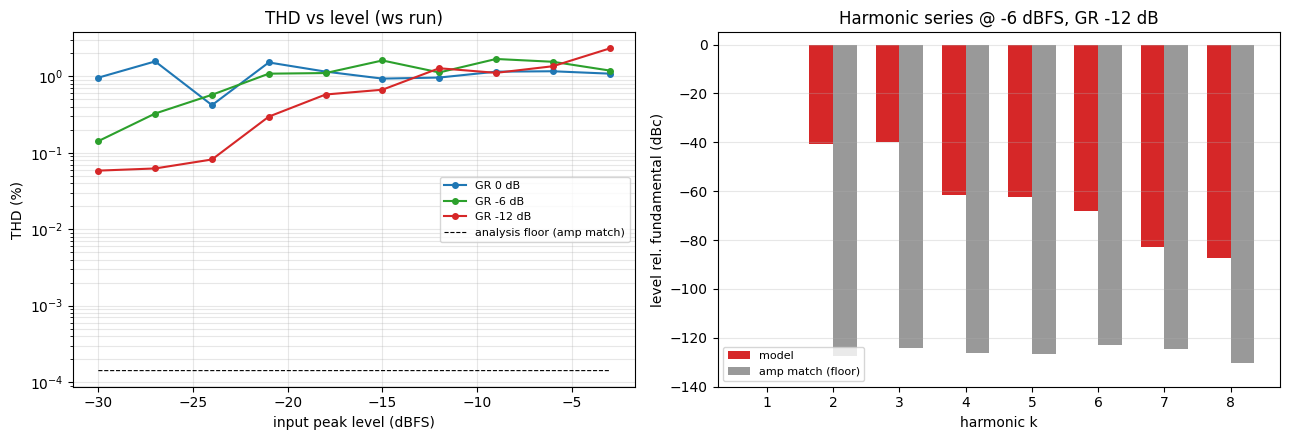

In [4]:
# -- 3. Harmonic bench test: THD of the learned device ---------------------
# Steady sine (on-bin f0), constant GR, 3 s; harmonics read from the last
# 65536 samples. The amplitude-matched input is a pure scaled sine, so its
# harmonics measure the numerical floor of the analysis itself.
# NOTE: tones are out-of-distribution for a model trained on music - this is
# exactly the point of a bench test (standard VA-modelling methodology).

F0 = on_bin_freq(1000.0)
K = knobs(-8.0, 3.0, 0.4, 4.0)
LEVELS = np.arange(-30, -2, 3.0)
GR_DEPTHS = [0.0, -6.0, -12.0]
N_HARM = 8


@torch.no_grad()
def bench(level_dbfs, gr_db):
    x = sine(F0, 3.0, level_dbfs)
    g = torch.full_like(x, gr_db)
    MODEL.reset_states()
    y = MODEL(x.unsqueeze(0), g.unsqueeze(0), K).squeeze(0)
    return x, g, y


thd = {d: [] for d in GR_DEPTHS}
floor = []
for lv in LEVELS:
    for d in GR_DEPTHS:
        x, g, y = bench(lv, d)
        h = harmonic_levels(y[0].numpy(), SR, F0, N_HARM)
        thd[d].append(100 * np.sqrt((h[1:] ** 2).sum()) / (h[0] + 1e-18))
    h0 = harmonic_levels(amplitude_match(x, g)[0].numpy(), SR, F0, N_HARM)
    floor.append(100 * np.sqrt((h0[1:] ** 2).sum()) / (h0[0] + 1e-18))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for d, c in zip(GR_DEPTHS, ("#1f77b4", "#2ca02c", "#d62728")):
    ax1.semilogy(LEVELS, thd[d], "o-", ms=4, color=c, label=f"GR {d:g} dB")
ax1.semilogy(LEVELS, floor, "k--", lw=0.8, label="analysis floor (amp match)")
ax1.set_xlabel("input peak level (dBFS)"); ax1.set_ylabel("THD (%)")
ax1.set_title(f"THD vs level ({TAG} run)"); ax1.grid(alpha=0.3, which="both")
ax1.legend(fontsize=8)

x, g, y = bench(-6.0, -12.0)
h = harmonic_levels(y[0].numpy(), SR, F0, N_HARM)
h_ref = harmonic_levels(amplitude_match(x, g)[0].numpy(), SR, F0, N_HARM)
ks = np.arange(1, N_HARM + 1)
ax2.bar(ks - 0.18, amp_to_db(h / (h[0] + 1e-18)), 0.36, label="model", color="#d62728")
ax2.bar(ks + 0.18, amp_to_db(h_ref / (h_ref[0] + 1e-18)), 0.36,
        label="amp match (floor)", color="#999")
ax2.set_xlabel("harmonic k"); ax2.set_ylabel("level rel. fundamental (dBc)")
ax2.set_title("Harmonic series @ -6 dBFS, GR -12 dB"); ax2.grid(alpha=0.3, axis="y")
ax2.legend(fontsize=8); ax2.set_ylim(-140, 5)
fig.tight_layout()
fig.savefig(OUT / f"04_harmonics_{TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

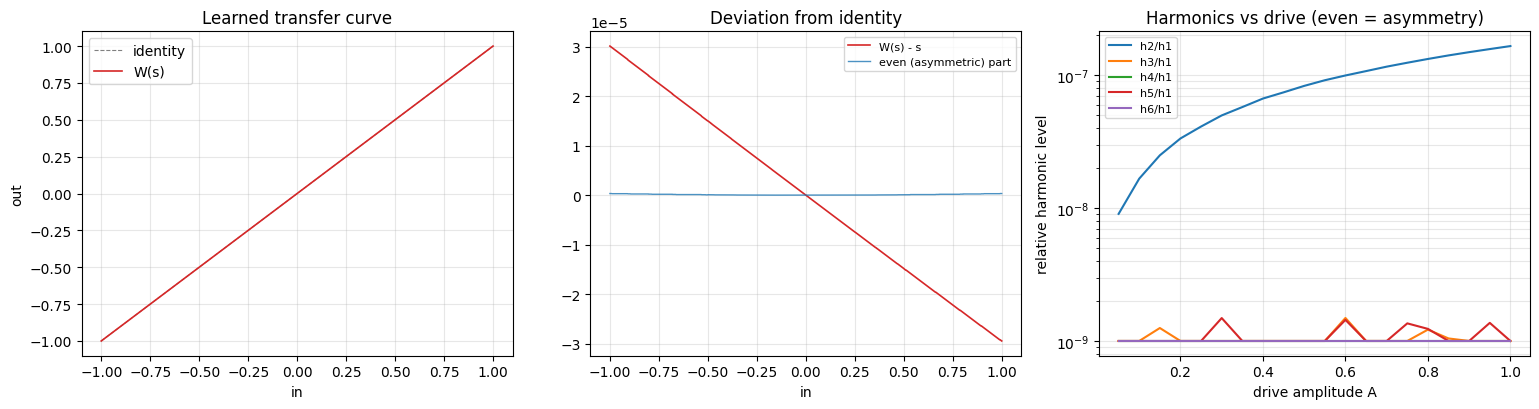

full-drive even/odd harmonic energy ratio: 158.30


In [5]:
# -- 4. Waveshaper curve analysis (ws run only) -----------------------------
# Exact harmonic decomposition of the memoryless curve: W(A cos(theta)) is
# periodic, so its Fourier coefficients ARE the harmonic amplitudes at drive A.
# Even harmonics <-> asymmetry of the curve.

if hasattr(MODEL, "waveshaper"):
    ws = MODEL.waveshaper
    s = torch.linspace(-1, 1, 1001).view(1, 1, -1)
    with torch.no_grad():
        w = ws(s).flatten().numpy()
    s_np = s.flatten().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
    axes[0].plot(s_np, s_np, "--", color="gray", lw=0.8, label="identity")
    axes[0].plot(s_np, w, color="#d62728", lw=1.2, label="W(s)")
    axes[0].set_xlabel("in"); axes[0].set_ylabel("out")
    axes[0].set_title("Learned transfer curve"); axes[0].grid(alpha=0.3); axes[0].legend()

    axes[1].plot(s_np, w - s_np, color="#d62728", lw=1.2, label="W(s) - s")
    sym = 0.5 * ((w - s_np) + (w - s_np)[::-1])         # even part of the deviation
    axes[1].plot(s_np, sym, color="#1f77b4", lw=1.0, alpha=0.8,
                 label="even (asymmetric) part")
    axes[1].set_xlabel("in"); axes[1].set_title("Deviation from identity")
    axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

    drives = np.linspace(0.05, 1.0, 20)
    H = np.stack([waveshaper_harmonics(ws, a, n_harm=6) for a in drives])
    for k in range(1, 6):
        axes[2].semilogy(drives, np.maximum(H[:, k] / (H[:, 0] + 1e-18), 1e-9),
                         label=f"h{k+1}/h1")
    axes[2].set_xlabel("drive amplitude A"); axes[2].set_ylabel("relative harmonic level")
    axes[2].set_title("Harmonics vs drive (even = asymmetry)")
    axes[2].grid(alpha=0.3, which="both"); axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "04_waveshaper_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    even = float(np.sqrt((H[-1, 1::2] ** 2).sum()))     # h2, h4, h6 at full drive
    odd = float(np.sqrt((H[-1, 2::2] ** 2).sum()))      # h3, h5
    print(f"full-drive even/odd harmonic energy ratio: {even/(odd+1e-18):.2f}")
else:
    print("Additive run selected - no waveshaper. "
          "Set SELECTED_GAIN_PRIOR_RUN to the gain_prior_ws_* run for this cell.")

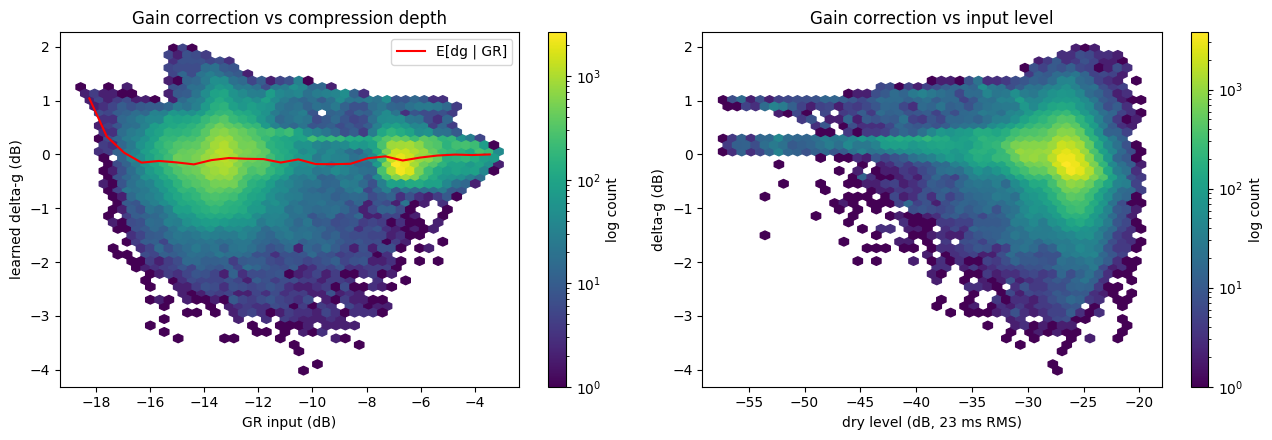

mean|dg| = 0.365 dB | P99|dg| = 1.81 dB (bound: 12.0 dB)


In [6]:
# -- 5. Delta-g behaviour: where does the model override the prior? ---------
# Joint statistics over 3 validation pairs x 60 s, decimated to decorrelate.

from exp_common import short_env_db

dg_all, gr_all, lvl_all = [], [], []
for song_i, setting_i in VAL_PAIRS[:3]:
    d, w, g = load_pair(setting_i, song_i, start_sec=30.0, duration_sec=60.0)
    _, dl, _ = stream_gain_prior_parts(MODEL, d, g, params_for(setting_i))
    sl = slice(SR, None, 63)                       # skip 1 s cold start, decimate
    dg_all.append(dl[0].numpy()[sl])
    gr_all.append(g[0].numpy()[sl])
    lvl_all.append(short_env_db(d, 1024)[sl])
dg = np.concatenate(dg_all); grs = np.concatenate(gr_all); lvl = np.concatenate(lvl_all)
m = lvl > -60                                       # drop silence
dg, grs, lvl = dg[m], grs[m], lvl[m]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hb = axes[0].hexbin(grs, dg, gridsize=45, bins="log", cmap="viridis")
bins = np.linspace(grs.min(), grs.max(), 25)
mid = 0.5 * (bins[1:] + bins[:-1])
cond = [dg[(grs >= a) & (grs < b)].mean() if ((grs >= a) & (grs < b)).any() else np.nan
        for a, b in zip(bins[:-1], bins[1:])]
axes[0].plot(mid, cond, "r-", lw=1.5, label="E[dg | GR]")
axes[0].set_xlabel("GR input (dB)"); axes[0].set_ylabel("learned delta-g (dB)")
axes[0].set_title("Gain correction vs compression depth")
axes[0].legend(); fig.colorbar(hb, ax=axes[0], label="log count")

hb2 = axes[1].hexbin(lvl, dg, gridsize=45, bins="log", cmap="viridis")
axes[1].set_xlabel("dry level (dB, 23 ms RMS)"); axes[1].set_ylabel("delta-g (dB)")
axes[1].set_title("Gain correction vs input level")
fig.colorbar(hb2, ax=axes[1], label="log count")
fig.tight_layout()
fig.savefig(OUT / f"04_delta_g_behaviour_{TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"mean|dg| = {np.abs(dg).mean():.3f} dB | P99|dg| = {np.percentile(np.abs(dg), 99):.2f} dB "
      f"(bound: {MODEL.delta_max_db} dB)")

## Reading the results

- **Explained fraction & `color/wet`**: how much of the ≈ 8 % coloration residual the
  non-multiply path (waveshaper `(W(s)−s)` + additive `c`) actually synthesises. Near
  zero would reproduce the §5.2 additive-run finding (a 33-param linear readout of 32
  LSTM units cannot phase-track broadband harmonic content); a clearly non-zero,
  spectrally-matched share is the waveshaper composition doing its intended job. The
  residual-spectra plot shows *where* the explained/unexplained energy sits.
- **THD curves**: a real VCA compressor's THD *rises with drive and with GR depth*.
  If the model's THD hugs the analysis floor, it is functionally a pure time-varying
  gain; if THD lifts level-dependently, the waveshaper is generating
  physically-plausible harmonics (§3's exact `W(A·cosθ)` decomposition confirms the
  even/odd structure and whether it scales with drive).
- **Δg vs GR depth**: `E[Δg | GR]` sloping away from 0 at deep compression reveals a
  *systematic* prior error (the label's RMS smear is depth-dependent); a symmetric
  cloud around 0 means Δg only does transient re-timing. P99 far below the 12 dB
  bound confirms the tanh saturation regime isn't active (one of §5.2's suspects).